# 12 — Adversarial Attacks Beyond Vision: Text Classifiers — Lab

In the previous lessons we perturbed **images**: add a tiny amount of noise to the pixels and the classifier's decision changes while the picture looks the same. This lab asks what that idea looks like for **text**, and why it does not carry over directly.

It has two parts. First you fine-tune a sentiment classifier (DistilBERT on SST-2, using 1,024 training and 512 test sentences) and evaluate it, exactly like the Lesson 5 lab. Then you study how this classifier *reads* text (as discrete token IDs) and how sensitive its output is to small edits of a sentence. This classifier is the target that later steps of the lesson will probe with word-level and character-level modifications.

## Objectives
- Articulate why gradient-based, noise-style image perturbations do not apply directly to text, and what makes the text perturbation space discrete.
- Fine-tune a Hugging Face Transformer sentiment classifier on SST-2 and report accuracy and macro-F1 on a held-out slice.
- Inspect how a text classifier tokenizes a sentence, and observe how the tokens and the predicted probabilities change when the sentence is edited.

## Prerequisites
- Read the Lesson 5 lab on fine-tuning a pre-trained checkpoint for sentiment classification.
- Know the image perturbation idea from the earlier lessons (a small L-infinity change to the pixels, found with the gradient of the loss).
- Know Python functions, dictionaries, and basic model evaluation.

## Required Software and Packages
- Python 3.10 or newer
- `transformers` 4.40 or newer
- `datasets` 2.18 or newer
- `scikit-learn` 1.3 or newer
- `matplotlib` and `numpy`
- PyTorch 2.1 or newer

## Environment and Setup
Run the next cell in an environment with network access. The model and the SST-2 split download from the Hugging Face Hub on first use.

In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

## Background: why image noise does not carry over to text

An image classifier takes a grid of **continuous** numbers. Adding a small amount of noise gives another perfectly valid image, and because the whole pipeline is differentiable, the gradient of the loss with respect to the pixels tells us which direction to push. A change of a few intensity levels per pixel is invisible to a person.

A text classifier is different in four ways:

1. **The input is discrete.** A sentence is a sequence of words (characters), and the model reads it as a sequence of integer **token IDs**. There is no "0.01 of a word": you can replace a word with another word, but nothing lies in between.
2. **Tokenization is not differentiable.** The step that turns text into IDs, and the embedding lookup that follows, break the gradient path. A gradient exists with respect to the *embedding vectors*, but not with respect to the words themselves.
3. **Nearby numbers are not nearby meanings.** Token ID 3835 and token ID 3836 are unrelated words, so adding a small number to an ID (the analogue of adding noise) does not produce a slightly different word. A perturbation in embedding space, meanwhile, usually lands on a point that is not the embedding of any real word.
4. **Changes are visible and constrained.** A person notices a replaced word, a broken grammar, or a changed meaning far more easily than a 2/255 pixel change. A useful text perturbation must therefore keep the meaning, stay grammatical, and stay readable.

| | Image | Text |
|---|---|---|
| Input space | Continuous pixel values | Discrete characters, words, token IDs |
| Smallest change | An arbitrarily small numeric step | Replace, insert, or delete a whole word or character |
| Gradient of the loss w.r.t. the input | Available directly | Not defined for words, only for embeddings |
| Constraint on the perturbation | Small norm (for example L-infinity, `eps`) | Meaning preserved, grammatical, readable |
| How the search is done | Follow the gradient | Search over a discrete set of candidate edits |

So attacks on text search over **discrete edits**, such as word substitutions or character-level changes, and use the model's output scores to decide which edit to keep. The figure in Section 2 shows the contrast, and Section 5 shows how sensitive the classifier is to such edits.

## Exercise Instructions
1. Load `distilbert-base-uncased`, add a two-class sequence-classification head, and tokenize the SST-2 slices: **1,024** sentences for training and **512** for testing, both taken from the SST-2 training split. (2 min)
2. Look at how the tokenizer turns text into IDs, and why image-style noise has no meaning there. (3 min)
3. Fine-tune the checkpoint with `Trainer` for 3 epochs and evaluate accuracy and macro-F1 on the held-out slice. (6 min)
4. Compare the tokens and the predicted probabilities of a sentence and a few lightly edited versions of it. (4 min)

In [2]:
checkpoint = "distilbert-base-uncased"
dataset = load_dataset(
    "nyu-mll/glue",
    "sst2",
    split={"train": "train[:1024]", "test": "train[1024:1536]"},
)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2,
)

print("train sentences:", len(dataset["train"]), " test sentences:", len(dataset["test"]))
print("example:", dataset["train"][0]["sentence"], "-> label", dataset["train"][0]["label"], "(0 = negative, 1 = positive)")

def tokenize_batch(batch):
    # Tokenize the sentence field with truncation enabled.
    return tokenizer(batch["sentence"], truncation=True)

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


train sentences: 1024  test sentences: 512
example: hide new secretions from the parental units  -> label 0 (0 = negative, 1 = positive)


## 2. What the model actually sees: token IDs

The classifier never sees the words. The tokenizer splits a sentence into tokens (whole words or word pieces), and each token becomes an integer ID that is used to look up an embedding vector.

The figure contrasts the two worlds. On the left, an image with a tiny amount of noise added is still a valid image and looks unchanged. On the right, the token IDs of a sentence: the token that has the *next number* as its ID is an unrelated word, so "adding a little noise to the ID" does not give a slightly different word.

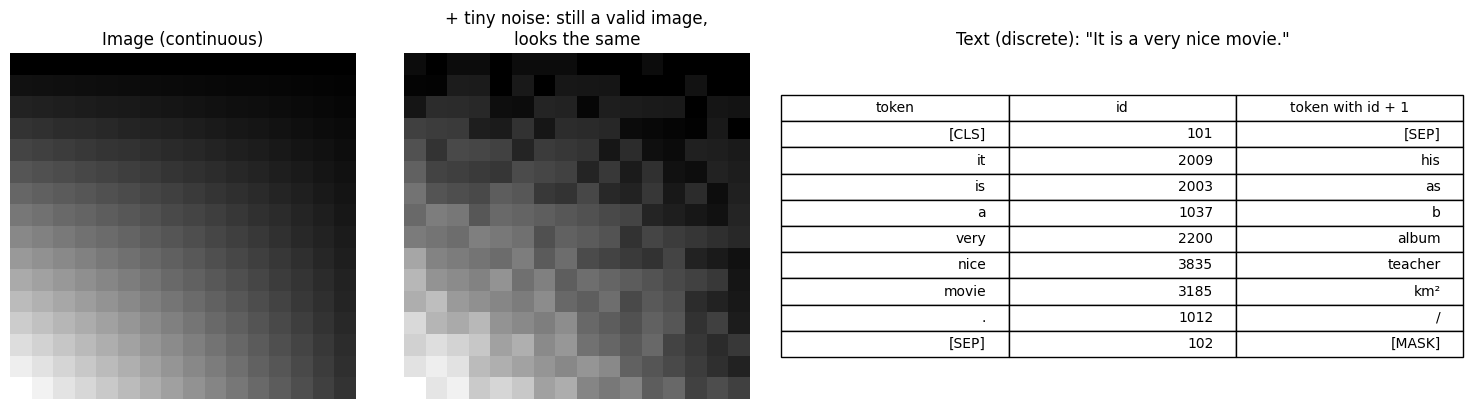

In [3]:
sentence = "It is a very nice movie."
ids = tokenizer(sentence)["input_ids"]
tokens = tokenizer.convert_ids_to_tokens(ids)
neighbours = [tokenizer.convert_ids_to_tokens(i + 1) for i in ids]   # the token whose ID is one larger

# Illustrative image side: a smooth 16x16 image, and the same image with tiny +/- noise.
rng = np.random.default_rng(0)
image = np.outer(np.linspace(0, 1, 16), np.linspace(1, 0.2, 16))
noisy = np.clip(image + 0.05 * np.sign(rng.standard_normal(image.shape)), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 1, 1.8]})
axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Image (continuous)")
axes[1].imshow(noisy, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("+ tiny noise: still a valid image,\nlooks the same")
for ax in axes[:2]:
    ax.axis("off")

axes[2].axis("off")
table = axes[2].table(
    cellText=[[t, i, n] for t, i, n in zip(tokens, ids, neighbours)],
    colLabels=["token", "id", "token with id + 1"],
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
axes[2].set_title(f'Text (discrete): "{sentence}"')
plt.tight_layout()
plt.show()

## 3. Fine-tune the classifier

The steps are the same as in the Lesson 5 lab, with a larger data slice (1,024 training sentences instead of 512) and a 512-sentence test slice. Labels are `0` = negative and `1` = positive.

In [4]:
tokenized = dataset.map(tokenize_batch, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized = tokenized.remove_columns(["sentence", "idx"])

# Do NOT use tokenized.set_format("torch")

def compute_metrics(prediction):
    predictions = np.argmax(prediction.predictions, axis=-1)
    labels = prediction.label_ids
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="./m12-sst2-checkpoint",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_strategy="epoch",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)
trainer.train()

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.470172,0.374842,0.865234,0.860429
2,0.194072,0.373804,0.869141,0.866575
3,0.080460,0.413227,0.878906,0.876463


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=192, training_loss=0.24823463956514993, metrics={'train_runtime': 766.1514, 'train_samples_per_second': 4.01, 'train_steps_per_second': 0.251, 'total_flos': 28372860949632.0, 'train_loss': 0.24823463956514993, 'epoch': 3.0})

In [5]:
metrics = trainer.evaluate(tokenized["test"])
print(f"accuracy={metrics['eval_accuracy']:.3f}")
print(f"macro_f1={metrics['eval_macro_f1']:.3f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.080460,0.413227,3,0.878906,0.876463


accuracy=0.879
macro_f1=0.876


## Expected Outputs
The training cell prints one loss record per epoch. The final lines print `accuracy=...` and `macro_f1=...`. Correct training normally produces accuracy at or above `0.880` and macro-F1 near the same value on the 512-sentence test slice.

## 4. Ask the classifier for probabilities

To see how the model reacts to text edits we need its output probabilities, not just the predicted label. The function below takes any list of sentences and returns `[P(negative), P(positive)]` for each. Try it on your own sentences.

In [6]:
def predict_proba(texts):
    # Returns an array of shape (len(texts), 2): [P(negative), P(positive)] per sentence.
    trainer.model.eval()
    enc = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(trainer.model.device)
    with torch.no_grad():
        logits = trainer.model(**enc).logits
    return logits.softmax(dim=-1).cpu().numpy()

print(predict_proba(["It is a very nice movie.", "It is a very bad movie."]).round(3))

[[0.008 0.992]
 [0.992 0.008]]


## 5. How sensitive is the classifier to small text edits?

Because the model reads token IDs, an edit that looks tiny to a person can change the token sequence, and with it the output. The function below compares an original sentence with edited versions. For each version it prints the tokens (the tokens that differ from the original are shown in **bold** inside `[[double brackets]]`) and the probabilities.

Three kinds of edit are worth noticing:

- **Word substitution** (`nice` to `good`): a different token ID, but a similar meaning.
- **Word removal** (dropping `very`): the sequence gets shorter.
- **Character edit** (`nice` to `nlce`): a person still reads the word, but the tokenizer splits the misspelling into different word pieces, so the model sees an entirely different sequence.

Run it as-is, then change `original` and `variants` to sentences of your own.

In [7]:
BOLD, RESET = "\033[1m", "\033[0m"

def compare_variants(original, variants):
    # Print the tokens and P(negative)/P(positive) of a sentence and its edited versions.
    base_tokens = tokenizer.tokenize(original)

    def show(label, text):
        toks = tokenizer.tokenize(text)
        shown = " ".join(f"{BOLD}[[{t}]]{RESET}" if t not in base_tokens else t for t in toks)
        p_neg, p_pos = predict_proba([text])[0]
        print(f"{label:<10}| {text}")
        print(f"{'':<10}| tokens : {shown}")
        print(f"{'':<10}| P(neg) = {p_neg:.3f}   P(pos) = {p_pos:.3f}   ->  {'positive' if p_pos > p_neg else 'negative'}\n")

    show("original", original)
    for k, text in enumerate(variants, 1):
        show(f"variant {k}", text)

original = "It is a very nice movie."
variants = [
    "It is a very good movie.",    # word substitution
    "It is a nice movie.",         # word removal
    "It is a very nice film.",     # word substitution
    "It is a very nlce movie.",    # character edit
]
compare_variants(original, variants)

original  | It is a very nice movie.
          | tokens : it is a very nice movie .
          | P(neg) = 0.008   P(pos) = 0.992   ->  positive

variant 1 | It is a very good movie.
          | tokens : it is a very [[good]] movie .
          | P(neg) = 0.008   P(pos) = 0.992   ->  positive

variant 2 | It is a nice movie.
          | tokens : it is a nice movie .
          | P(neg) = 0.008   P(pos) = 0.992   ->  positive

variant 3 | It is a very nice film.
          | tokens : it is a very nice [[film]] .
          | P(neg) = 0.008   P(pos) = 0.992   ->  positive

variant 4 | It is a very nlce movie.
          | tokens : it is a very [[nl]] [[##ce]] movie .
          | P(neg) = 0.012   P(pos) = 0.988   ->  positive



In [19]:
original = "This is an outstanding and unforgettable movie."

variants = [
    # semantic-preserving paraphrase
    "This is an exceptional and unforgettable movie.",
    # Latin substitutions
    "This is an оutstanding and unforgеttable movie.",
    # token splitting
    "This is an out.standing and unfor-gettable movie.",
    "This is an out-standing and un-forgettable movie."
    # misspelling
    "This is an outstаnding and unforgetable movie.",
    # stronger misspelling, still human-readable
    "This is an outstаnding and unforgettаble movie.",
]
compare_variants(original, variants)

original  | This is an outstanding and unforgettable movie.
          | tokens : this is an outstanding and un ##for ##get ##table movie .
          | P(neg) = 0.013   P(pos) = 0.987   ->  positive

variant 1 | This is an exceptional and unforgettable movie.
          | tokens : this is an [[exceptional]] and un ##for ##get ##table movie .
          | P(neg) = 0.013   P(pos) = 0.987   ->  positive

variant 2 | This is an оutstanding and unforgеttable movie.
          | tokens : this is an [[о]] [[##uts]] [[##tan]] [[##ding]] and un ##for [[##g]] [[##е]] [[##tta]] [[##ble]] movie .
          | P(neg) = 0.989   P(pos) = 0.011   ->  negative

variant 3 | This is an out.standing and unfor-gettable movie.
          | tokens : this is an [[out]] . [[standing]] and un ##for [[-]] [[get]] ##table movie .
          | P(neg) = 0.990   P(pos) = 0.010   ->  negative

variant 4 | This is an out-standing and un-forgettable movie.This is an outstаnding and unforgetable movie.
          | tokens : thi

In [20]:
original = "The movie was brilliant and captivating."

variants = [
    # semantic paraphrase
    "The movie was excellent and mesmerizing.",
    # Latin substitutions
    "The movie was brіllіant and captіvatіng.",
    # dash perturbation
    "The movie was bril-liant and capti-vating.",
    # misspelling
    "The movie was brilllant and captivatng.",
    # more aggressive misspelling
    "The movie was brilant and captvating.",
]
compare_variants(original, variants)

original  | The movie was brilliant and captivating.
          | tokens : the movie was brilliant and capt ##ivating .
          | P(neg) = 0.007   P(pos) = 0.993   ->  positive

variant 1 | The movie was excellent and mesmerizing.
          | tokens : the movie was [[excellent]] and [[me]] [[##sm]] [[##eri]] [[##zing]] .
          | P(neg) = 0.007   P(pos) = 0.993   ->  positive

variant 2 | The movie was brіllіant and captіvatіng.
          | tokens : the movie was [[br]] [[##і]] [[##ll]] [[##і]] [[##ant]] and capt [[##і]] [[##vat]] [[##і]] [[##ng]] .
          | P(neg) = 0.342   P(pos) = 0.658   ->  positive

variant 3 | The movie was bril-liant and capti-vating.
          | tokens : the movie was [[br]] [[##il]] [[-]] [[lia]] [[##nt]] and capt [[##i]] [[-]] [[va]] [[##ting]] .
          | P(neg) = 0.939   P(pos) = 0.061   ->  negative

variant 4 | The movie was brilllant and captivatng.
          | tokens : the movie was [[br]] [[##ill]] [[##lan]] [[##t]] and capt [[##iva]] [[##t]]

## Questions and Tasks
1. Why can we not add "a little noise" to the token IDs of a sentence the way we add noise to pixels?
2. Look at the character-edit variant above. A person still reads `nlce` as `nice`. What did the tokenizer do with it, and why can that change the model's output?
3. Write two sentences of your own and pass them to `compare_variants`, each with three edited versions. Which kind of edit (substitution, removal, or character edit) changed the probabilities the most in your examples?

In [9]:
accuracy = metrics["eval_accuracy"]
macro_f1 = metrics["eval_macro_f1"]
assert 0.0 <= accuracy <= 1.0
assert 0.0 <= macro_f1 <= 1.0
assert accuracy >= 0.85, f"accuracy below target: {accuracy:.3f}"
assert predict_proba(["a fine movie"]).shape == (1, 2)
print(f"PASS accuracy={accuracy:.3f}, macro_f1={macro_f1:.3f}")

PASS accuracy=0.879, macro_f1=0.876


## Optional
Fine-tune again with only 256 training sentences and compare the accuracy and the probabilities that `compare_variants` reports. Does a less-trained model react more or less strongly to the same edits?

## Completion Criteria

You have completed this lab when:

- **The classifier is trained.** The fine-tuning cell trains for 3 epochs on 1,024 sentences, and the verification cell prints `PASS` with an accuracy of at least 88% on the 512-sentence test slice.
- **You explain why images and text differ.** Using the token table in Section 2, you can explain in your own words why image-style noise has no direct counterpart in text (discrete tokens, non-differentiable tokenization, unrelated neighbouring IDs, meaning that must be preserved).
- **You ran your own example.** Your `my_original` sentence and all four variants (sentiment-word synonym, low-sentiment-word substitution, word removal, character edit) ran through `compare_variants`.
- **You recorded your results.** In a markdown cell, fill in a table with one row per variant:

  | Variant | Edit type | Tokens that changed | P(positive) | Change vs. original | Predicted label changed? |
  |---|---|---|---|---|---|

- **You interpret what you saw.** You answer, using your table:
  1. Which edit type moved the probability the most, and which the least?
  2. Did editing a sentiment-carrying word matter more than editing a low-sentiment word? What does that suggest about the words the classifier relies on?
  3. For your character edit, how did the tokenizer split the misspelled word compared with the original, and why can that change the output even though a person reads the word the same way?
- **You repeated it on a second sentence.** Run the same four edit types on a sentence of the *opposite* sentiment (for example, a negative review if the first was positive), and state whether the classifier was equally sensitive.
- **You write a short reflection (3-4 sentences).** Explain what your experiments show about how susceptible text classifiers are to small edits, and why this is harder to reason about and defend against than image noise (a discrete search space, and edits that must keep the meaning, the grammar, and the readability).